# Lecture 4: Interventions on Language Models

Can we control a model's behavior through manipulating its internals? 

In the previous lecture, we surveyed methods for **probing** information in the activations of language models. From there, we gave an example of how to construct effective **interventions** from these probes to control the model's behavior. 

This lecture, we'll survey different interventions one could apply to a language model to **remove** information, **understand** intermediate computations, or **control** the final behavior of the model. Along the way, we'll also learn that external interventions make assumptions about the model's internal structure - and that these assumptions don't necessarily describe the model's internal behavior!

### ✍ Learning goals

By the end of the lesson, we hope you will be familiar with different types of interventions we can apply to language models, including

* **Ablations**: structured modifications for removing information in the model.
* **Interchange interventions**: swapping activations between different inputs for identifying causally relevant components.
* **Steering**: interventions optimized to induce behavior in the model.

## 0️⃣ Setup

Run this code to get started!

In [1]:
from IPython.display import clear_output
import plotly.io as pio

try:
    import google.colab
    is_colab = True
except ImportError:
    is_colab = False

if is_colab:
    pio.renderers.default = "colab"
    !git clone https://github.com/cs221m/cs221m-course.git
    %cd cs221m-course
    !uv sync
else:
    pio.renderers.default = "plotly_mimetype+png"
    !uv sync
    !plotly_get_chrome -y

clear_output()

## 1️⃣ Ablations: identifying information by removing it

### Overview

Last lecture, we concluded with **difference-in-means steering** - an intervention for controlling a model's behavior, derived from information that we identified in its internal state.

But there's settings where we might want to **remove** information from the model, instead of decoding it. For instance, we might want to ensure our model doesn't memorize certain things, like the answer to a benchmark or copyrighted material. In this section, we'll go through one method, **iterative nullspace projection (INLP)**, for removing biases that the model migth have acquired from its training data.

As we'll later see, external interventions such as these make certain assumptions about how information is structured in the model, which may not always hold. In fact, it's not a likely guarantee that language models represent concepts or memorized text separately from how they represent key variables for next-token predictions - meaning that it might not be possible to "erase" information from a model without harming its general capabilities.

### Investigating gender bias

For this section, we'll focus on a small example for evaluating gender bias in language models. Machine learning models can often amplify the biases of their training data. By inspecting the model's internals, we might be able to identify - and potentially remove - these biases from our model.

For this section, we'll use a 1-billion parameter model developed by the Allen-AI OLMo team. The OLMo project aims to create **fully open-source** models - publicly documenting not only the model weights, but also the training code, data collection and cleaning pipeline, and the pre-training dataset itself - providing an awesome contribution to those interested in studying language models!

In [2]:
# load olmo-1B
from nnsight import LanguageModel

model = LanguageModel("allenai/OLMo-2-0425-1B")

clear_output() # suppress download info

One kind of bias is stereotype: models are likely to pick up, and often amplify, unintended correlations in their training dataset. Here, we'll focus on **profession stereotypes**, showing that language models associate "nurse" with "she" and "doctor" with "he". This bias has been shown to have downstream effects, such as different treatment of female- and male-presenting applicants by automatic resume evaluators.

For our case, we'll draw on our previous lecture for doing behavioral analysis, and evaluate gender bias in our model using **minimal pairs**. We'll compare the probability that "he" vs. "she" is associated with a profession using the following template.
$$
p(\text{she} \mid \text{``The [nurse] said that''}) \ \textit{vs.} \ p(\text{he} \mid \text{``The [nurse] said that''})
$$

Substituting "doctor" for "nurse", we can see that the ratio between "she" and "he" flips!

In [ ]:
prompt_f = "The nurse said that"
prompt_m = "The doctor said that"

he_token_id = model.tokenizer(" he").input_ids[0]
she_token_id = model.tokenizer(" she").input_ids[0]

with model.trace(prompt_f):
    logits_f = model.output.logits.save() # (1, num tokens, vocab size)
probs_f = logits_f.softmax(dim=-1) # (1, num tokens, vocab size)

with model.trace(prompt_m):
    logits_m = model.output.logits.save() # (1, num tokens, vocab size)
probs_m = logits_m.softmax(dim=-1) # (1, num tokens, vocab size)

clear_output() # suppress first-time download info

print(f"Prompt (F):", prompt_f)
print(f"P(he | F): {probs_f[0, -1, he_token_id]:.3f}")
print(f"P(she | F): {probs_f[0, -1, she_token_id]:.3f}")
print('-' * 40)
print(f"Prompt (M):", prompt_m)
print(f"P(he | M): {probs_m[0, -1, he_token_id]:.3f}")
print(f"P(she | M): {probs_m[0, -1, she_token_id]:.3f}")

Prompt (F): The nurse said that
P(he | F): 0.057
P(she | F): 0.118
----------------------------------------
Prompt (M): The doctor said that
P(he | M): 0.112
P(she | M): 0.046


### ✏ **Exercise 1**

Let's create a quantitative metric to evaluate the bias of our model.

Implement the code below to define a gender bias metric and use it to compute the bias of our model across the provided set of professions.

*Hint: This is purposefully vague, but you don't need to get fancy! Computing some ratio between p("he") and p("she") is all we're looking for.*

In [ ]:
# define and implement a quantitative bias metric
professions_m = ["doctor", "coder", "boss", "pilot", "lawyer", "agent"]
professions_f = ["nurse", "homemaker", "secretary", "flight attendant", "paralegal", "nanny"]

# compute bias on this dataset!
prompts_m = [f"The {profession} said that" for profession in professions_m]
prompts_f = [f"The {profession} said that" for profession in professions_f]

def measure_bias(probs, stereotype : str):
  """
  Compute model bias for a single prompt and its corresponding stereotype.

  probs : torch.Tensor (vocab size,)
    probabilities predicted by the model for the next token
  stereotype : str ("m" or "f")
    whether the prompt came from `professions_m` or `professions_f`
  """
  ################# YOUR CODE HERE #################
  return 0
  ##################################################

# collect logits
with model.trace(prompts_m):
  logits_m = model.output.logits[:, -1, :].save()

with model.trace(prompts_f):
  logits_f = model.output.logits[:, -1, :].save()

# compute bias
biases = []
for logits in logits_m:
  probs = logits.softmax(dim=-1)
  biases.append(measure_bias(probs, "m"))

for logits in logits_f:
  probs = logits.softmax(dim=-1)
  biases.append(measure_bias(probs, "f"))

mean_bias = sum(biases) / len(biases)
print(f"Mean bias: {mean_bias:.2f}")

Mean bias: 3.81


Describe your metric. What's the value that an unbiased model would get? According to your metric, is our model biased?

> FILL IN YOUR ANSWER HERE

### Bias in activations

Can we trace the bias in our model back to its internal activations? As we saw in our previous lecture, **probes** can help us decode information that the model's intermediate layers might represent. Here, we'll use PCA to visualize the activations at an intermediate layer of the model. Please revisit the previous lecture if you'd like a refresher on visualizing activations with PCA. 

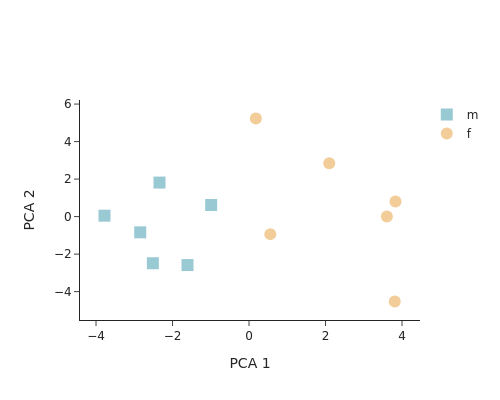

In [13]:
import torch
from sklearn.decomposition import PCA
import plotly.graph_objects as go

# copy-pasted dataset from previous exercise
professions_m = ["doctor", "coder", "boss", "pilot", "lawyer", "agent"]
professions_f = ["nurse", "homemaker", "secretary", "flight attendant", "paralegal", "nanny"]

prompts_m = [f"The {profession} said that" for profession in professions_m]
prompts_f = [f"The {profession} said that" for profession in professions_f]

LAYER = 5
n = len(professions_m)

# collect activations over the last profession token (before "said that")
with torch.no_grad():
    with model.trace(prompts_m):
        activations_m = model.model.layers[LAYER].output[:, -3, :].save() # (n, hidden dim)
    
    with model.trace(prompts_f):
        activations_f = model.model.layers[LAYER].output[:, -3, :].save() # (n, hidden dim)

# reduce to 2-dim with PCA
pca = PCA(n_components=2)
all_activations = torch.cat([activations_m, activations_f]).cpu().float().numpy() # (2n, hidden_dim)
low_dim_activations = pca.fit_transform(all_activations) # (2n, 2)

# plot 
fig = go.Figure()

fig.add_trace(go.Scatter(
  x=low_dim_activations[:n, 0],
  y=low_dim_activations[:n, 1],
  mode='markers',
  marker=dict(symbol='square', color="rgba(0, 124, 146, 0.4)", size=12),
  name='m',
  hovertext=professions_m,
))

fig.add_trace(go.Scatter(
  x=low_dim_activations[n:, 0],
  y=low_dim_activations[n:, 1],
  mode='markers',
  marker=dict(symbol='circle', color="rgba(223, 131, 0, 0.4)", size=12),
  name='f',
  hovertext=professions_f,
))

fig.update_layout(
  template='simple_white',
  width=500,
  height=400,
  xaxis_title='PCA 1',
  yaxis_title='PCA 2',
)

fig.show()

As we can see, there seems to be a fairly clear linear separation in the model's activations over male-stereotyped and female-stereotyped professions in our small dataset. It's not a guarantee that the model is using this exact information (maybe it's representing the gender stereotypes in a non-linear subspace, or at a different layer). However, if we have some way of guaranteeing that there's no possible way to distinguish between activations over female- and male-stereotyped professions, then we can also guarantee that the model wouldn't treat these professions any differently. This is the motivation behind a particular method for information removal, called **iterative nullspace projection (INLP)**.

### Iterative nullspace projection (INLP)

As we can see, our model's activations over different professions are linearly separable by whether they're more stereotypically associated with male- or female-presenting people. Our model might use this information to sway it's prediction for the next token ("he" vs. "she") or for more general downstream tasks - then again, it might not. One thing for sure, though, is that the model **can't** use any information that's absent from its activations! So if we have a way of making sure that we couldn't decode the gender of the profession from the activation, then the model couldn't decode it either.

<img src="figures/lecture_4/inlp_cropped.gif" width="600" alt="logit lens"/>

This is the motivation for **iterative nullspace projection (INLP)**, a method for removing a linear concept from a model's activations. The idea is to repeatedly find and erase the direction that a linear probe uses to detect that concept.

INLP works as follows.
1. **Train a probe**: fit a probe on the current activations to classify the concept (e.g., gender).
2. **Project onto the nullspace**: remove the probe's weight direction from all activations, so no linear probe can use that direction anymore.
3. **Repeat**: each new iteration removes another linear direction that encodes the concept.

After enough iterations, no linear probe should be able to recover gender from the activations.

In [14]:
# implement iterative nullspace projection
import numpy as np
from sklearn.linear_model import LogisticRegression

def inlp(activations_m, activations_f, n_iters=10):
    results = []

    for i in range(n_iters):
        # train probe to classify m vs. f
        X = np.concatenate([activations_m, activations_f], axis=0)
        y = np.array(["m"] * len(activations_m) + ["f"] * len(activations_f))

        probe = LogisticRegression(fit_intercept=False, random_state=42, max_iter=1000)
        probe.fit(X, y)

        # evaluate probe and save intermediate result
        probe_accuracy = probe.score(X, y)
        results.append({
            "activation_m": activations_m.copy(),
            "activation_f": activations_f.copy(),
            "iteration": i,
            "probe_accuracy": probe_accuracy
        })

        # if we fooled the probe, we're done!
        if probe_accuracy < 0.51:
            break

        # project to the nullspace of the classifier
        probe_weights = probe.coef_[0] # (hidden dim,) 
        probe_magnitude = np.dot(probe_weights, probe_weights)
        activations_m = activations_m - np.outer(activations_m @ probe_weights, probe_weights) / probe_magnitude
        activations_f = activations_f - np.outer(activations_f @ probe_weights, probe_weights) / probe_magnitude

    return results

The code below runs INLP on our small gender bias dataset. Within a few iterations, it makes it so that no linear probe can predict the stereotype behind the profession. We can visualize the results of the INLP method by plotting the PCA visualization of the activations after each iteration. By the final iteration, the "m" and "f" activations cluster together so that no linear direction cleanly separates them.

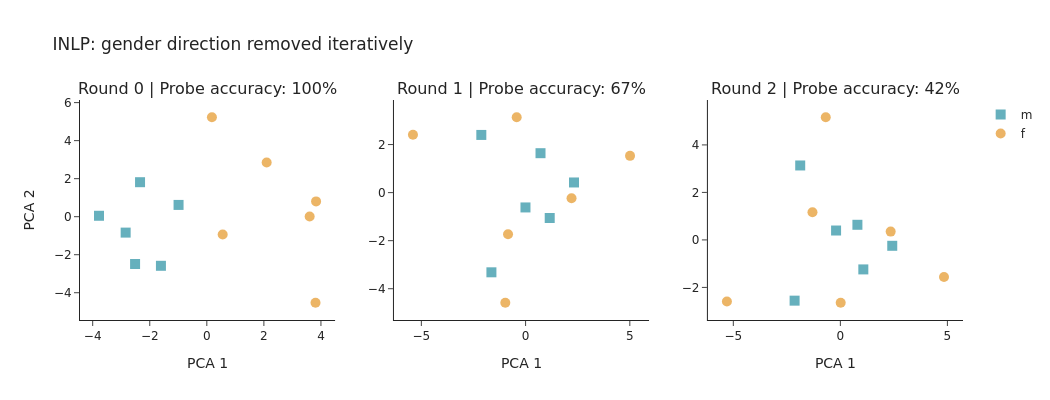

In [15]:
from plotly.subplots import make_subplots

results = inlp(activations_m.cpu().float().numpy(), activations_f.cpu().float().numpy())
n = len(professions_m)

subplot_titles = [
    f"Round {r['iteration']} | Probe accuracy: {r['probe_accuracy']:.0%}"
    for r in results
]

fig = make_subplots(rows=1, cols=len(results), subplot_titles=subplot_titles)

for col, r in enumerate(results, start=1):
    acts_m_snap = r["activation_m"]
    acts_f_snap = r["activation_f"]

    # refit PCA on each snapshot so the axes capture the variance that's actually present
    pca = PCA(n_components=2)
    proj = pca.fit_transform(np.concatenate([acts_m_snap, acts_f_snap], axis=0))

    fig.add_trace(go.Scatter(
        x=proj[:n, 0], y=proj[:n, 1],
        mode='markers',
        marker=dict(symbol='square', color="rgba(0, 124, 146, 0.6)", size=10),
        name='m',
        showlegend=(col == 1),
        hovertext=professions_m,
    ), row=1, col=col)

    fig.add_trace(go.Scatter(
        x=proj[n:, 0], y=proj[n:, 1],
        mode='markers',
        marker=dict(symbol='circle', color="rgba(223, 131, 0, 0.6)", size=10),
        name='f',
        showlegend=(col == 1),
        hovertext=professions_f,
    ), row=1, col=col)

fig.update_layout(
    template='simple_white',
    width=350 * len(results),
    height=400,
    title_text='INLP: gender direction removed iteratively',
)
fig.update_xaxes(title_text='PCA 1')
fig.update_yaxes(title_text='PCA 2', col=1)

fig.show()

### ✏ **Exercise 2**

Did INLP reduce our model's bias? Let's investigate! 

We'll re-use the `measure_bias` function you designed in Exercise 1 to measure the bias of the model after INLP. To do this, we'll **replace the activation** of the model with the **INLP activation** for each prompt.

*Hint: Look back at the steering notebook (or look ahead at the interchange intervention section) to remind yourself how to replace activations with `nnsight`!*

In [ ]:
# measure bias of model after INLP
import torch

# replace activations at this location (this is how we collected the activations)
LAYER = 5
TOKEN_POSITION = -3

# INLP results: replace the existing activations with these activations
inlp_activations_m = torch.tensor(results[-1]['activation_m']).to(model.device) # (6, hidden dim)
inlp_activations_f = torch.tensor(results[-1]['activation_f']).to(model.device) # (6, hidden dim)

# run model forward, but with new INLP activation
with model.trace(prompts_m):
  ############################# YOUR CODE HERE #############################
  # replace the model's activations at layer 5 and token -3 with the INLP activations!
  
  ##########################################################################
  logits_m = model.output.logits[:, -1, :].save()

with model.trace(prompts_f):
  ############################# YOUR CODE HERE #############################
  # repeat for `inlp_activations_f`
  
  ##########################################################################
  logits_f = model.output.logits[:, -1, :].save()

# compute bias just as before!
biases = []
for logits in logits_m:
  probs = logits.softmax(dim=-1)
  biases.append(measure_bias(probs, "m"))

for logits in logits_f:
  probs = logits.softmax(dim=-1)
  biases.append(measure_bias(probs, "f"))

mean_bias = sum(biases) / len(biases)
print(f"Mean bias: {mean_bias:.2f}")

Mean bias: 1.68


Did INLP successfully reduce the model's bias? Did it remove it completely? How can you tell?

> FILL IN YOUR ANSWER HERE

### 🧠 Takeaways

In this section, we went over a method for removing information from a model (**iterative nullspace projection**, or **INLP**), and saw how it could be used to de-bias a language model on a toy dataset.

External interventions, such as ones that try to "erase" information from language models, must make assumptions about the model's internal structure. In the next section, we'll set up and play around with a toy model that exemplifies the fact that these assumptions might not always hold for complicated non-linear models. In fact, it's not even a guarantee that zeroing out model components removes information within the model!

## 2️⃣ Interchange interventions: what's causally relevant?

In the previous section, we looked at a method for removing information from the model. One of the assumptions it made is that information is only accessible to the model if it's in a linear dimension (notice how the model could still store gender information in non-linear dimensions). 

In this section, we'll see is that removing information doesn't always equate to deleting it from the model's memory. In other words, external interventions that assume a certain structure in the model might have unexpected consequences for the resulting behavior. Specificaly, we'll spoof the assumption that "0 means nothing". To do this, look at a toy neural network that computes the max of two positive numbers, a simple but non-linear function.

### Toy example: neural network for $\max$

<img src="figures/lecture_4/max.png" width="600" alt="logit lens"/>

Let's set up a small neural network that takes in two positive numbers, $x$ and $y$, and returns $\text{max}(x, y)$. Since $\text{max}$ is non-linear, the model must rely on its activation functions to compute it.

Our `MaxNN` uses the $\text{ReLU}$ function like an `if` statement: when $x > y$, $\text{ReLU}(x - y)$ is positive; but when $x < y$, $\text{ReLU}(x - y) = 0$. This means that $0$ has a special value for our model -- it's a flag for which number to select as the maximum.

In [33]:
# define a neural network that computes the max of two positive numbers
import torch

class MaxNN(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.l1 = torch.nn.Linear(2, 4, bias=False)
    self.l2 = torch.nn.Linear(4, 2, bias=False)
    self.l3 = torch.nn.Linear(2, 1, bias=False)
    self.relu1 = torch.nn.ReLU()
    self.relu2 = torch.nn.ReLU()

    self.l1.weight.data = torch.tensor([
        [1., -1.],  # x - y
        [-1., 1.],  # y - x
        [1., 0.],   # x
        [0., 1.]    # y
    ])

    self.l2.weight.data = torch.tensor([
        [-100., 0., 0., 1.],  # y if x < y else 0
        [0., -100., 1., 0.]   # x if y < x else 0
    ])

    self.l3.weight.data = torch.tensor([
        [1., 1.]
    ])

  def forward(self, x):
    x = self.l1(x)
    x = self.relu1(x)
    x = self.l2(x)
    x = self.relu2(x)
    x = self.l3(x)
    return x

We can visualize an example walk-through of our model. The key idea is that, since $x < y$ or $y < x$, there will always be one zero in the first layer after ReLU. Likewise, there will always be a zero in the second layer (since we're subtracting an absurdly large number from one of the two neurons at that layer).

<img src="figures/lecture_4/max_example.png" width="1200" alt="logit lens"/>

### ✏ **Exercise 3**

Let's test out our model a bit: play around with different inputs and see if you can detect any edge cases!

In [35]:
maxnn = MaxNN()

# play around with the input numbers!
inputs = torch.tensor([1., 3.])

maxnn(inputs).item()

3.0

What are some edge cases you notice?

> FILL IN YOUR ANSWER HERE

*Note: there's a few edge cases, but for our analysis they aren't important. Going forward, let's assume all inputs are positive, and that there's always a maximum value.*

### Zero-out interventions

How does our model know which number is the maximum? A first step might be to intervene on the model to remove information from it; if we successfully mess up the model's computation, then we know we found an important neuron.

Let's start with zero-out interventions, which do what they say: select a neuron, and set its value to 0. If it didn't change the model's output, then we would say it didn't store any relevant information for the model's computation.

To start, let's zero out the third layer's activation. Perhaps unsurprisingly, doing this will always return zero, because this is the last layer of the model!

In [36]:
import nnsight

model = nnsight.NNsight(MaxNN())

In [37]:
# zero out the output of the last layer
inputs = torch.tensor([1., 3.])

original_output = model(inputs)

with model.trace(inputs):
  layer3 = model.l3.output # get layer 3's activation
  layer3[0] = 0. # set the first value in layer 3 to 0
  intervention_output = model.output.save() # save the model's output

print("Before:", original_output.item())
print("After:", intervention_output.item())

Before: 3.0
After: 0.0


Let's get more interesting: can we erase the output information already in the first layer?

In [38]:
# zero out a neuron in the first layer's output
inputs = torch.tensor([1., 3.])

original_output = model(inputs)

with model.trace(inputs):
  layer1 = model.l1.output # get layer 1's activation
  layer1[-1] = 0. # set the last value in layer 1 to 0
  intervention_output = model.output.save() # save the model's output

print("Before:", original_output.item())
print("After:", intervention_output.item())

Before: 3.0
After: 0.0


Looks like the answer might be yes!

### ✏ **Exercise 4**

Looks like zeroing out the last neuron in the first layer changes the output of our model to zero! Is this always the case?

Find 2 more inputs where the intervention has the same effect (that is, the output is 0 after the intervention) and 2 inputs where the intervention has a **different** effect.

*Hint: Play around with different inputs! What pattern do you notice?*

In [39]:
# copy-pasted code for convenience

######### YOUR CODE HERE ##########
inputs = torch.tensor([1., 3.])
###################################

original_output = model(inputs)

with model.trace(inputs):
  layer1 = model.l1.output # get layer 1's activation
  layer1[-1] = 0. # set the last value in layer 1 to 0
  intervention_output = model.output.save() # save the model's output

print("Before:", original_output.item())
print("After:", intervention_output.item())

Before: 3.0
After: 0.0


What were the inputs where the zero-out intervention had the **same effect**? What were the inputs where the intervention had a **different effect**? What was the new effect, and what did you change about the inputs to achieve it?

> FILL IN YOUR ANSWER HERE

### Zeroing out multiple neurons

Looks like, depending on where we intervene on the first layer, zeroing out activations either:

* Erases the answer (the model outputs 0)
* Doesn't do anything! (the model's output stays the same)

What happens if we intervene on multiple neurons? Can that tell us anything useful?

Let's intervene on the first two neurons. What happens?

In [41]:
# zero out multiple neurons - play around with different inputs!
inputs = torch.tensor([1., 3.])

original_output = model(inputs)

with model.trace(inputs):
  layer1 = model.l1.output # get layer 1's activation
  layer1[:2] = 0. # intervene on both neurons
  intervention_output = model.output.save() # save the model's output

print("Before:", original_output.item())
print("After:", intervention_output.item())

Before: 3.0
After: 4.0


Strange! It seems that the model forgot all about $\max$ and now just adds the inputs together.

What if we intervene on, say, the 2nd and 4th neurons?

In [ ]:
# zero out multiple neurons - play around with different inputs!
inputs = torch.tensor([1., 3.])

original_output = model(inputs)

with model.trace(inputs):
  layer1 = model.l1.output # get layer 1's activation
  layer1[[1, 3]] = 0. # intervene on both neurons
  intervention_output = model.output.save() # save the model's output

print("Before:", original_output.item())
print("After:", intervention_output.item())

Before: 3.0
After: 1.0


Even stranger - the model is now calculating $\min$ instead of $\max$!

We'll figure out *why* this happened later, but for now, let's recap all that can happen when we zero out the model's activations. For our toy example, zero-out interventions can cause the model to:
1. Change its answer to 0.
2. Do nothing.
3. Return the sum of the inputs.
4. Return the smallest input.

Clearly, zeroing out does much more than erasing information in our model. This can often happen in neural networks: thanks to their non-linearity, neural networks can give $0$ a special meaning that's different from just "no information".

To understand our model, we should come up with an intervention that's agnostic to the model's inner workings; we don't want to assume which numbers the model uses to represent certain information, we simply want to know where this information is stored.

That is, instead of stipulating values that the activations might take on, we can **reuse activation values across different inputs**  to test where something is stored in the model! This approach of swapping interventions is usually called **interchange interventions** or **activation patching**.

### Interchange interventions

Since zero-out interventions led to all sorts of different behaviors, it's hard to tell what the model is doing internally. This can be the case when 0 has a meaningful value for the model's internal computation! What would it look like to make an intervention that doesn't make assumptions about the values that the model's internal activations could take on?

One intervention method that's agnostic to the values of the model's activations is called **interchange intervention** (also known as **activation patching**). The idea behind interchange interventions is to **reuse activation values from different inputs** to predictably change the model's behavior. 

An interchange intervention works by taking paired inputs, a **base** and a **source**, and **swapping activations from the source to the base**. Here are the steps we'd take to perform an interchange intervention.

1. **Collect source activation** by running the model forward on the source input.
2. **Run the model forward on the base input** and, in the middle of the computation,
3. **Swap base activation with source activation** so that the resulting computation uses the new source activation. Lastly,
4. **Save the output of the model after the swap** - this is the **counterfactual** output of the model, where we kept everything the same **except for the activation value**.

If the interchange intervention caused the model to change its output, we can say that the intermediate activation has a **causal effect** on the model's final output!

Let's perform an interchange intervention where we swap the entire value of layer 1. What do you expect the output to be?

In [10]:
# interchange intervention (from source into base)
source_input = torch.tensor([7., 2.])
base_input = torch.tensor([1., 3.])

# 1. get source activation
with model.trace(source_input):
  source_activation = model.l1.output.save()

# 2. swap base activation with source activation
with model.trace(inputs):
  base_activation = model.l1.output
  base_activation[:] = source_activation[:] # swap values
  intervention_output = model.output.save() # save the model's output


base_output = model(base_input)
source_output = model(source_input)

print("Base output:", base_output.item())
print("Source output:", source_output.item())
print("Intervention output:", intervention_output.item())

Base output: 3.0
Source output: 7.0
Intervention output: 7.0


Perhaps unsurprisingly, the intervention changes the base output to the source output. This is because, after the intervention, the model behaves exactly like it would've behaved if we originally plugged in the source input.

But what if we intervene on only a *part* of the model's activations? This is where things get interesting!

This is what it looks like to intervene on the last two neurons:

<img src="figures/lecture_4/interchange_one_cropped.gif" width="800" alt="logit lens"/>

In [11]:
# interchange intervention on last two neurons

source_input = torch.tensor([7., 2.])
base_input = torch.tensor([1., 3.])

# 1. get source activation
with model.trace(source_input):
  source_activation = model.l1.output.save()

# 2. swap base activation with source activation
with model.trace(inputs):
  base_activation = model.l1.output
  base_activation[2:] = source_activation[2:] # swap values
  intervention_output = model.output.save() # save the model's output


base_output = model(base_input)
source_output = model(source_input)

print("Base output:", base_output.item())
print("Source output:", source_output.item())
print("Intervention output:", intervention_output.item())

Base output: 3.0
Source output: 7.0
Intervention output: 2.0


What do you expect will happen when we intervene on the first two neurons of our model? What's the new computation that it ends up performing?

<img src="figures/lecture_4/interchange_two_cropped.gif" width="800" alt="logit lens"/>

In [43]:
# interchange intervention on first two neurons

source_input = torch.tensor([7., 2.])
base_input = torch.tensor([1., 3.])

# 1. get source activation
with model.trace(source_input):
  source_activation = model.l1.output.save()

# 2. swap base activation with source activation
with model.trace(inputs):
  base_activation = model.l1.output
  base_activation[:2] = source_activation[:2] # swap values
  intervention_output = model.output.save() # save the model's output


base_output = model(base_input)
source_output = model(source_input)

print("Base output:", base_output.item())
print("Source output:", source_output.item())
print("Intervention output:", intervention_output.item())

Base output: 3.0
Source output: 7.0
Intervention output: 1.0


We're now starting to get a clearer picture of what's going on! When we intervene on the first two neurons, we change **the function** of the model from $\max$ to $\min$. When we intervene on the last two neurons, we change the **content** of the $\max$ function from the base input to the source inputs.

Putting it together, we can describe how the model computes $\max$:

1. Figure out whether $x > y$ or $y > x$, and store the result in the first two neurons.
2. Store a copy of $x$ and $y$ in the second two neurons.
2. If $x > y$, output the copy of $x$. If $y > x$, output the copy of $y$.

When we intervene, we either intervene on the result of the **comparison**, or on the **intermediate copies** stored by the model.

Interestingly, we figured this out without ever printing out the values of the model's activations! With interchange interventions, it doesn't matter whether the model uses zeroes or other numbers to represent its information. By re-using the model's own activation values, we can understand its computation without needing to make assumptions about its internal representations.

In the next lecture, we'll use interchange interventions to trace how information flows through language models. For the remainder of this lecture, we'll zoom back out and look at how we can directly optimize interventions in order to steer the behavior of language models.

## 3️⃣Steering: controlling models through their internal computations

### Representation fine-tuning (ReFT)